# Project 1 - Regression
### Predict total bikes that will be rented per day
#### Group V
+ Ana Isabel Moura, 20250168
+ Ayoub Mask, 20250183
+ Beatriz Lobão, 20250566
+ Joao Bernardino, 20250922
+ Lara Pereira, 20250921

## Initializations and data loading - Neural Networks

In [1]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as  sns
import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.neural_network import MLPRegressor
from yellowbrick.model_selection import LearningCurve
from yellowbrick.regressor import PredictionError
from sklearn.model_selection import RandomizedSearchCV
import random

#to plot in notebook
%matplotlib inline

In [2]:
# Loading the dataset and visualizing summary statistics
ds = pd.read_excel('/Users/anamoura/Desktop/MachineLearning/Project_01/bike_day_v2.xlsx', engine='openpyxl')
ds.describe(include='all').T

,count,mean,min,25%,50%,75%,max,std
instant,732.0,366.352459,1.0,183.75,366.5,549.25,731.0,211.236679
dteday,732,2012-01-01 08:27:32.459016448,2011-01-01 00:00:00,2011-07-02 18:00:00,2012-01-01 12:00:00,2012-07-02 06:00:00,2012-12-31 00:00:00,NaN
season,732.0,2.497268,1.0,2.0,3.0,3.0,4.0,1.110203
yr,732.0,0.501366,0.0,0.0,1.0,1.0,1.0,0.50034
mnth,732.0,6.523224,1.0,4.0,7.0,10.0,12.0,3.450769
holiday,732.0,0.028689,0.0,0.0,0.0,0.0,1.0,0.167044
weekday,730.0,3.00274,0.0,1.0,3.0,5.0,6.0,2.004793
workingday,732.0,0.68306,0.0,0.0,1.0,1.0,1.0,0.465602
schoolday,454.0,0.460352,0.0,0.0,0.0,1.0,1.0,0.498975
weathersit,732.0,1.394809,1.0,1.0,1.0,2.0,3.0,0.544718


In [3]:
ds

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,schoolday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6.0,0,0.0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0.0,0,0.0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1.0,1,1.0,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2.0,1,1.0,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3.0,1,1.0,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,727,2012-12-27,1,1,12,0,4.0,1,1.0,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
728,728,2012-12-28,1,1,12,0,5.0,1,1.0,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
729,729,2012-12-29,1,1,12,0,6.0,0,0.0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
730,730,2012-12-30,1,1,12,0,0.0,0,0.0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [4]:
# Show top rows
ds.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,schoolday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6.0,0,0.0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0.0,0,0.0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1.0,1,1.0,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2.0,1,1.0,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3.0,1,1.0,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


# Data understanding 

In [5]:
# Identifying columns with missing values and their counts
missing_data = ds.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

print("--- Columns with Missing Values ---")
if not missing_data.empty:
    print(missing_data)
else:
    print("No missing values found in the dataset.")

--- Columns with Missing Values ---
schoolday    278
weekday        2
dtype: int64


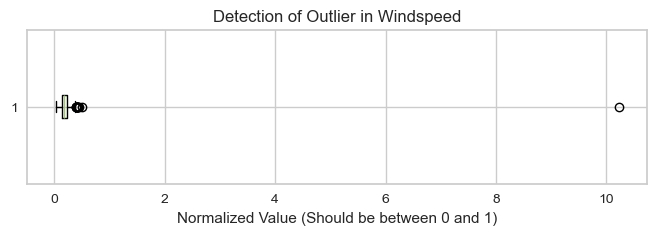

Percentage of missing data per column:
instant        0.000000
dteday         0.000000
season         0.000000
yr             0.000000
mnth           0.000000
holiday        0.000000
weekday        0.273224
workingday     0.000000
schoolday     37.978142
weathersit     0.000000
temp           0.000000
atemp          0.000000
hum            0.000000
windspeed      0.000000
casual         0.000000
registered     0.000000
cnt            0.000000
dtype: float64


In [6]:
# Visualize the windspeed outlier

plt.figure(figsize=(8, 2))
plt.boxplot(ds['windspeed'], vert=False)
plt.title('Detection of Outlier in Windspeed')
plt.xlabel('Normalized Value (Should be between 0 and 1)')
plt.show()

# Quantitative check on missing values
print("Percentage of missing data per column:")
print((ds.isnull().sum() / len(ds)) * 100)

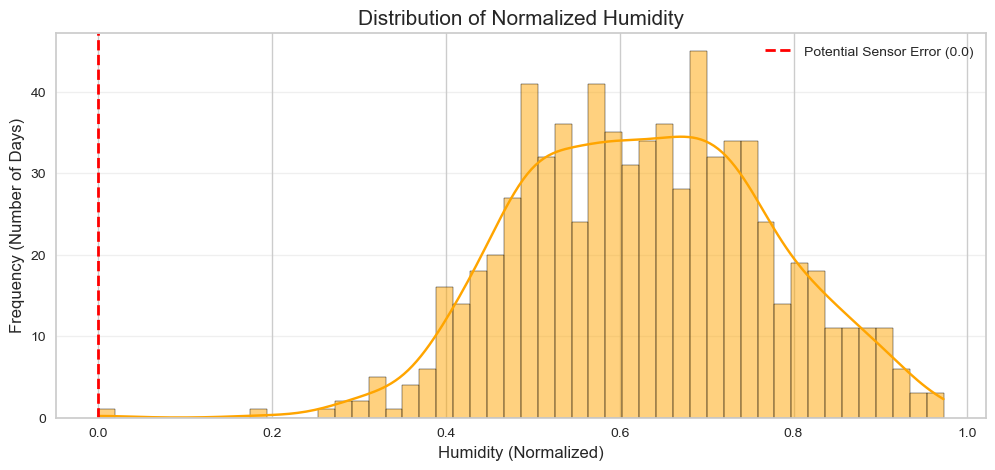

Number of days with 0.0 humidity: 1


In [7]:
# We use a distribution plot to see how many days have that 0.0 humidity
plt.figure(figsize=(12, 5))
sns.histplot(ds['hum'], bins=50, kde=True, color='orange')

# Adding a red line to highlight where the 0.0 values sit
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Potential Sensor Error (0.0)')

plt.title('Distribution of Normalized Humidity', fontsize=15)
plt.xlabel('Humidity (Normalized)', fontsize=12)
plt.ylabel('Frequency (Number of Days)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Counting exactly how many days have 0 humidity
zero_hum_count = (ds['hum'] == 0).sum()
print(f"Number of days with 0.0 humidity: {zero_hum_count}")

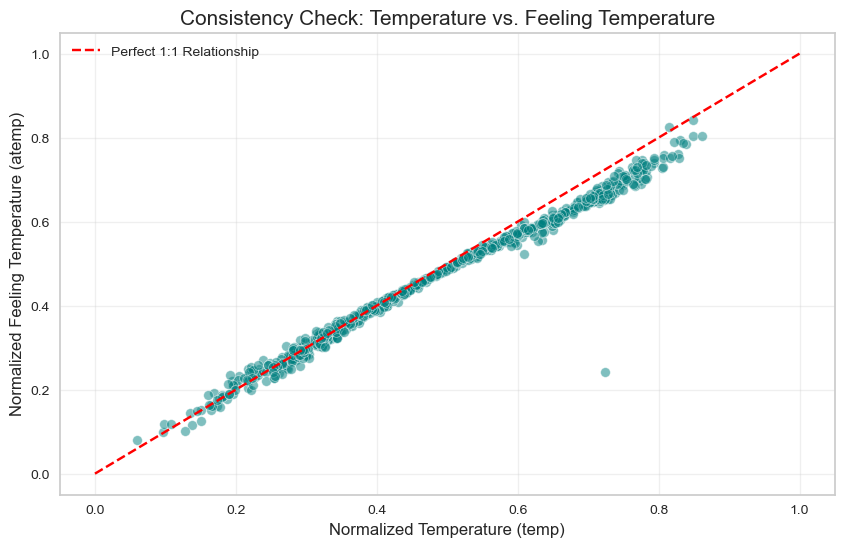

Correlation between temp and atemp: 0.9917


In [8]:
# Scatter plot to see if temp and atemp follow a logical linear relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ds, x='temp', y='atemp', alpha=0.5, color='teal')

# Adding a diagonal line for reference (where temp = atemp)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Perfect 1:1 Relationship')

plt.title('Consistency Check: Temperature vs. Feeling Temperature', fontsize=15)
plt.xlabel('Normalized Temperature (temp)', fontsize=12)
plt.ylabel('Normalized Feeling Temperature (atemp)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate the correlation coefficient
correlation = ds['temp'].corr(ds['atemp'])
print(f"Correlation between temp and atemp: {correlation:.4f}")

Multicollinearity presence between temp and atemp, two variables move so closely together they essentially provide the same information.

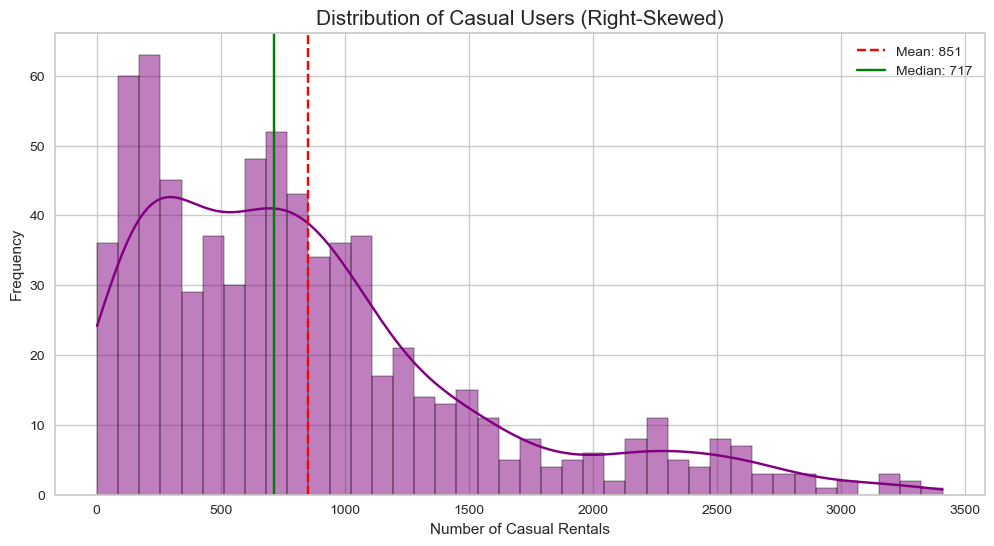

Skewness coefficient for Casual: 1.28


In [9]:
plt.figure(figsize=(12, 6))

# Histogram
sns.histplot(ds['casual'], kde=True, color='purple', bins=40)

# Add lines for Mean and Median 
plt.axvline(ds['casual'].mean(), color='red', linestyle='--', label=f"Mean: {ds['casual'].mean():.0f}")
plt.axvline(ds['casual'].median(), color='green', linestyle='-', label=f"Median: {ds['casual'].median():.0f}")

plt.title('Distribution of Casual Users (Right-Skewed)', fontsize=15)
plt.xlabel('Number of Casual Rentals')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Calculate the actual skewness coefficient
print(f"Skewness coefficient for Casual: {ds['casual'].skew():.2f}")

Upon analyzing the distribution of the casual variable, a significant positive (right) skew was identified (Mean: 851 vs. Median: 717). This indicates that while typical daily demand remains relatively stable around the median, the data is influenced by periodic "high-demand" outliers—likely corresponding to weekends, holidays, or favorable weather events. From a modeling perspective, this asymmetry suggests that a standard linear approach might over-estimate "normal" days or struggle with variance. We may need to consider data transformations (such as Log or Square Root) during the Data Preparation phase to normalize this feature and improve predictive stability.

In [10]:
# Check dimensions and data types
print(f"Dataset Shape: {ds.shape}")
print("\n--- Column Data Types ---")
print(ds.dtypes)

Dataset Shape: (732, 17)

--- Column Data Types ---
instant                int64
dteday        datetime64[ns]
season                 int64
yr                     int64
mnth                   int64
holiday                int64
weekday              float64
workingday             int64
schoolday            float64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


In [11]:
# Check if 'cnt' always equals the sum of casual and registered
integrity_errors = (ds['cnt'] != (ds['casual'] + ds['registered'])).sum()
print(f"Integrity Errors (cnt vs sum): {integrity_errors}")

Integrity Errors (cnt vs sum): 0


# Data Preparation

In [12]:
# Fix Weekday using calendar math (0=Sunday, 6=Saturday)
ds['weekday'] = ds['weekday'].fillna(ds['dteday'].dt.dayofweek.apply(lambda x: (x + 1) % 7))

# Fix Schoolday using the 'Workingday' logical constraint
ds['schoolday'] = ds['schoolday'].fillna(ds['workingday'])

print(f"Missing values after imputation: {ds[['weekday', 'schoolday']].isnull().sum().sum()}")

Missing values after imputation: 0


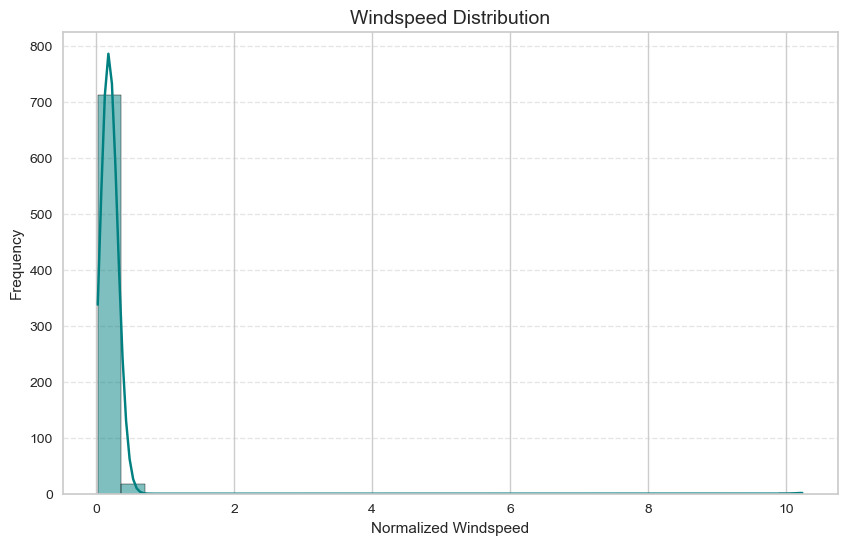

In [13]:

# Visualization of the windspeed distribution
plt.figure(figsize=(10, 6))

# Histogram 
sns.histplot(ds['windspeed'], kde=True, color='teal', bins=30)

# Formatting the chart
plt.title('Windspeed Distribution', fontsize=14)
plt.xlabel('Normalized Windspeed')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [14]:
# 1. Filter out the 10.23 error and find the maximum 'real' value
# we determine the value that sits at the very edge of the valid data
closest_value = ds[ds['windspeed'] <= 1.0]['windspeed'].max()

# 2. Display the result
print(f"The closest valid neighbor to the 10.23 error is: {closest_value}")

The closest valid neighbor to the 10.23 error is: 0.507463


In [15]:
# windspeed
# We look for the maximum value that is <= 1.0
closest_wind_neighbor = ds[ds['windspeed'] <= 1.0]['windspeed'].max()
ds.loc[ds['windspeed'] > 1.0, 'windspeed'] = closest_wind_neighbor

# Humidity
# We find the minimum value that is > 0
closest_hum_neighbor = ds[ds['hum'] > 0]['hum'].min()
ds.loc[ds['hum'] == 0, 'hum'] = closest_hum_neighbor

print(f"Correction Complete.")
print(f"Windspeed 10.23 moved to: {closest_wind_neighbor:.4f}")
print(f"Humidity 0.0 moved to: {closest_hum_neighbor:.4f}")


Correction Complete.
Windspeed 10.23 moved to: 0.5075
Humidity 0.0 moved to: 0.1879


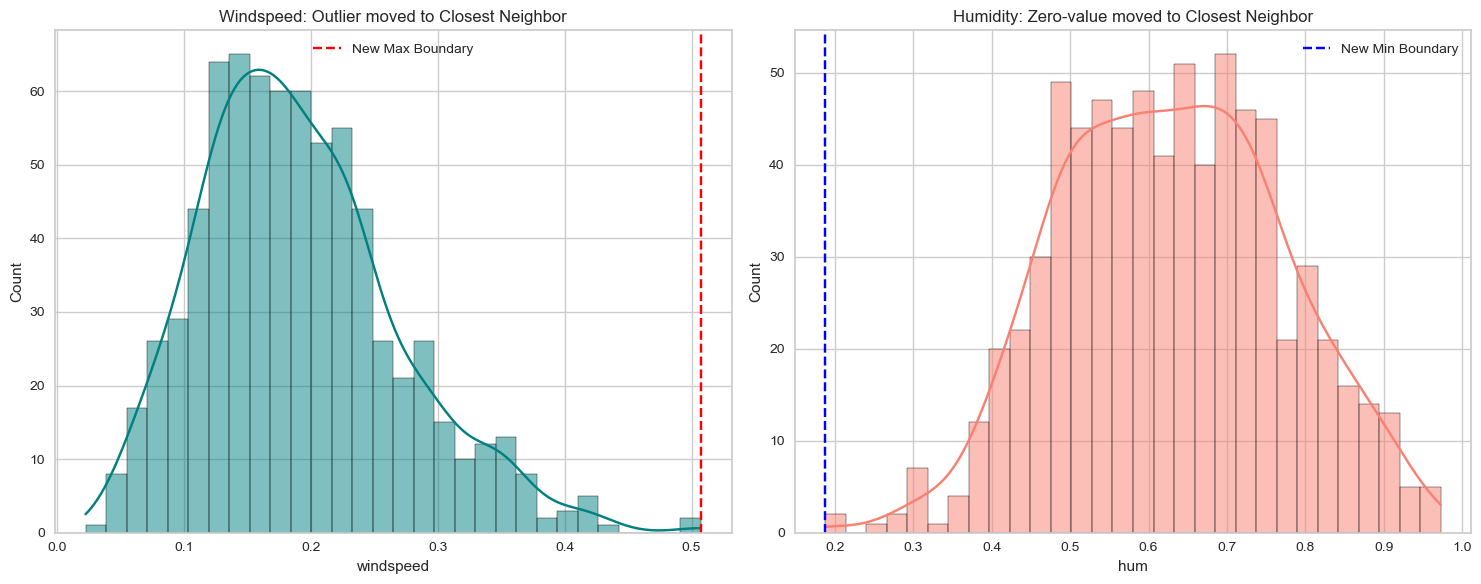

In [16]:
# visualization

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Windspeed Distribution
sns.histplot(ds['windspeed'], kde=True, ax=axes[0], color='teal', bins=30)
axes[0].set_title('Windspeed: Outlier moved to Closest Neighbor')
axes[0].axvline(closest_wind_neighbor, color='red', linestyle='--', label='New Max Boundary')
axes[0].legend()

# Plot 2: Humidity Distribution
sns.histplot(ds['hum'], kde=True, ax=axes[1], color='salmon', bins=30)
axes[1].set_title('Humidity: Zero-value moved to Closest Neighbor')
axes[1].axvline(closest_hum_neighbor, color='blue', linestyle='--', label='New Min Boundary')
axes[1].legend()

plt.tight_layout()
plt.show()

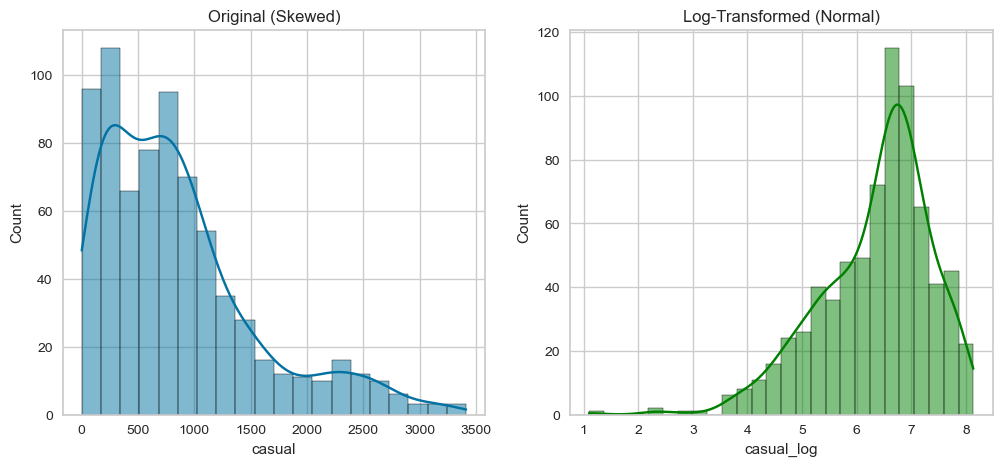

In [17]:
# Apply Log Transformation to normalize the 'Casual' distribution
ds['casual_log'] = np.log1p(ds['casual'])

# Visualization: Before vs After to demonstrate 'Normality'
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); sns.histplot(ds['casual'], kde=True).set_title("Original (Skewed)")
plt.subplot(1, 2, 2); sns.histplot(ds['casual_log'], kde=True, color='green').set_title("Log-Transformed (Normal)")
plt.show()

In [18]:
# visualizing the "registered" column
sns.histplot(ds['registered'], kde=True)

<Axes: xlabel='registered', ylabel='Count'>

In [19]:
# Dropping redundant, non-numeric, and index columns
# We drop 'instant' because it is just a row counter and adds no real value
ds = ds.drop(columns=['instant', 'atemp', 'casual', 'dteday'])

print("Feature Selection Complete: 'instant', 'atemp', and 'dteday' removed.")

Feature Selection Complete: 'instant', 'atemp', and 'dteday' removed.


In [20]:
# Create a 'Bad Weather' index
ds['temp_hum_interaction'] = ds['temp'] * ds['hum']

defining ideal conditions (the sweet spot) for when the demand is high based on the ideal temp and windspeed

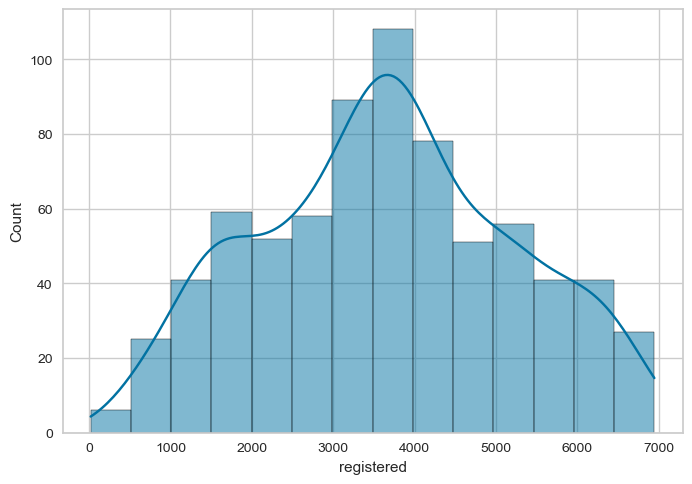

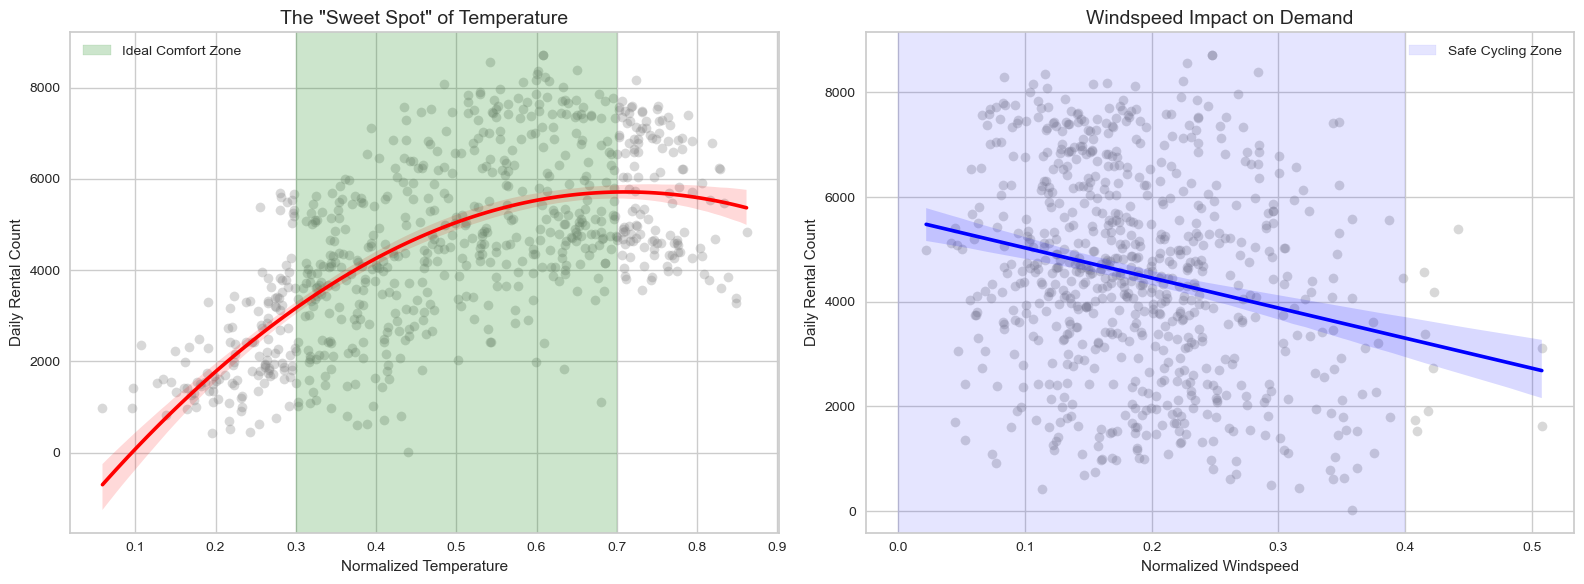

In [21]:
# Create a figure with two plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temperature vs Count
sns.regplot(data=ds, x='temp', y='cnt', order=2, ax=ax1, 
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})
ax1.set_title('The "Sweet Spot" of Temperature', fontsize=14)
# Shade the 0.3 to 0.7 region
ax1.axvspan(0.3, 0.7, color='green', alpha=0.2, label='Ideal Comfort Zone')
ax1.set_xlabel('Normalized Temperature')
ax1.set_ylabel('Daily Rental Count')
ax1.legend()

# Plot 2: Windspeed vs Count
sns.regplot(data=ds, x='windspeed', y='cnt', order=1, ax=ax2, 
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'blue'})
ax2.set_title('Windspeed Impact on Demand', fontsize=14)
# Shade the < 0.4 region
ax2.axvspan(0, 0.4, color='blue', alpha=0.1, label='Safe Cycling Zone')
ax2.set_xlabel('Normalized Windspeed')
ax2.set_ylabel('Daily Rental Count')
ax2.legend()

plt.tight_layout()
plt.show()

In [22]:
# adjusting thresholds based on the visuals
ds['ideal_conditions'] = ((ds['temp'] >= 0.35) & 
                                (ds['temp'] <= 0.75) & 
                                (ds['windspeed'] < 0.35)).astype(int)

In [23]:
# Create 'Dummy Variables' for seasons
# This creates 3 new columns (Spring, Summer, Fall) 
# We drop one (Winter) to avoid the "Dummy Variable Trap"
season_dummies = pd.get_dummies(ds['season'], prefix='season', drop_first=True)
ds = pd.concat([ds, season_dummies], axis=1)

# Now we can drop the original 'season' column
ds.drop(columns=['season'], inplace=True)

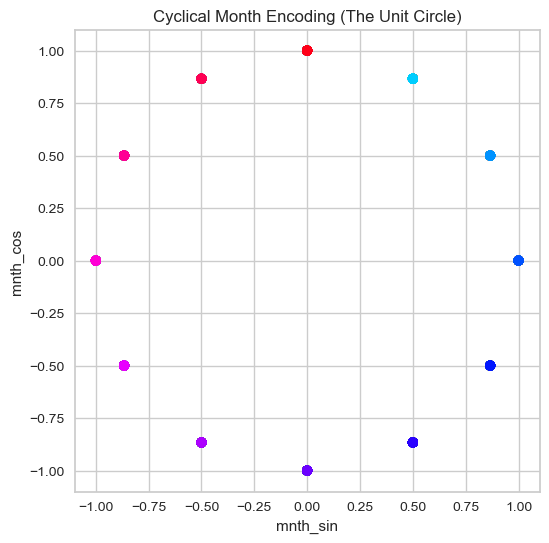

Cyclical encoding successful. The months now occupy a continuous circular space.


In [24]:
#  Apply the Trigonometric Transformation
# We use 2 * pi to represent a full circle (360 degrees)
ds['mnth_sin'] = np.sin(2 * np.pi * ds['mnth'] / 12)
ds['mnth_cos'] = np.cos(2 * np.pi * ds['mnth'] / 12)

# 2. Drop the original 'mnth' column as it is now redundant
ds.drop(columns=['mnth'], inplace=True)

# 3. VERIFICATION: scatter plot to see the 'Circular' nature
plt.figure(figsize=(6,6))
plt.scatter(ds['mnth_sin'], ds['mnth_cos'], c=ds.index, cmap='hsv')
plt.title("Cyclical Month Encoding (The Unit Circle)")
plt.xlabel("mnth_sin")
plt.ylabel("mnth_cos")
plt.grid(True)
plt.show()

print("Cyclical encoding successful. The months now occupy a continuous circular space.")

In [25]:
# Detailed summary of the dataset
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   yr                    732 non-null    int64  
 1   holiday               732 non-null    int64  
 2   weekday               732 non-null    float64
 3   workingday            732 non-null    int64  
 4   schoolday             732 non-null    float64
 5   weathersit            732 non-null    int64  
 6   temp                  732 non-null    float64
 7   hum                   732 non-null    float64
 8   windspeed             732 non-null    float64
 9   registered            732 non-null    int64  
 10  cnt                   732 non-null    int64  
 11  casual_log            732 non-null    float64
 12  temp_hum_interaction  732 non-null    float64
 13  ideal_conditions      732 non-null    int64  
 14  season_2              732 non-null    bool   
 15  season_3              7

In [26]:
# 1. Ensure weekday is treated as a category/string first so get_dummies works
ds['weekday'] = ds['weekday'].astype(int).astype(str)

# 2. Create dummies and drop the first one (Sunday/0) to avoid the Dummy Variable Trap
weekday_dummies = pd.get_dummies(ds['weekday'], prefix='day', drop_first=True, dtype=int)

# 3. Add them to the dataset
ds = pd.concat([ds, weekday_dummies], axis=1)

# 4. Drop 'weekday' column
ds.drop(columns=['weekday'], inplace=True)

# Verification
print("New columns added:")
print(ds.filter(like='day_').columns.tolist())

New columns added:
['day_1', 'day_2', 'day_3', 'day_4', 'day_5', 'day_6']


In [27]:
# Drop workingday 
ds.drop(columns=['workingday'], inplace=True)

In [28]:
# 1. Convert to string so get_dummies recognizes it as categorical
ds['weathersit'] = ds['weathersit'].astype(str)

# 2. Create dummies and drop '1' (Clear Weather) as the baseline
weather_dummies = pd.get_dummies(ds['weathersit'], prefix='weather', drop_first=True, dtype=int)

# 3. Add to dataset and drop original
ds = pd.concat([ds, weather_dummies], axis=1)
ds.drop(columns=['weathersit'], inplace=True)

# Verification
print("New weather columns:", ds.filter(like='weather_').columns.tolist())

New weather columns: ['weather_2', 'weather_3']


In [29]:
#  feature list
print("Current Features in 'ds':")
print(ds.columns.tolist())

Current Features in 'ds':
['yr', 'holiday', 'schoolday', 'temp', 'hum', 'windspeed', 'registered', 'cnt', 'casual_log', 'temp_hum_interaction', 'ideal_conditions', 'season_2', 'season_3', 'season_4', 'mnth_sin', 'mnth_cos', 'day_1', 'day_2', 'day_3', 'day_4', 'day_5', 'day_6', 'weather_2', 'weather_3']


In [30]:
# 1. Drop the columns causing high redundancy
cols_to_drop = ['registered','casual_log']

ds = ds.drop(columns=cols_to_drop)

# Now re-calculate VIF using ds_clean to see the improvement!

In [31]:
# Dropping both temp and hum from your dataframe 'ds'
ds.drop(columns=['temp', 'hum'], inplace=True)

In [32]:
# List of columns to convert
season_cols = ['season_2', 'season_3', 'season_4']

# Convert them to integer
ds[season_cols] = ds[season_cols].astype(int)

# Verify the change
print(ds[season_cols].dtypes)
ds[season_cols].head()

season_2    int64
season_3    int64
season_4    int64
dtype: object


,season_2,season_3,season_4
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


In [33]:
ds.drop(columns=['schoolday'], inplace=True)

In [34]:
# Create a 'Lag' feature: Yesterday's total rentals, and shift it by one row
ds['cnt_lag1'] = ds['cnt'].shift(1)

# Because the first day has no 'yesterday', it will be NaN. We drop it.
ds.dropna(inplace=True)

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Select only the numeric features you are using for the model
A = ds.select_dtypes(include=['number']).drop(columns=['cnt']) 

# 2. Calculate VIF for each
vif_data = pd.DataFrame()
vif_data["feature"] = A.columns
vif_data["VIF"] = [variance_inflation_factor(A.values, i) for i in range(len(A.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                 feature        VIF
18              cnt_lag1  23.867549
3   temp_hum_interaction  16.781329
6               season_3   8.584582
2              windspeed   5.938335
7               season_4   5.631758
5               season_2   5.506727
0                     yr   4.570023
4       ideal_conditions   4.468433
9               mnth_cos   4.372271
8               mnth_sin   4.011888
10                 day_1   1.979069
15                 day_6   1.888621
16             weather_2   1.887206
12                 day_3   1.880084
11                 day_2   1.877076
13                 day_4   1.865813
14                 day_5   1.858911
17             weather_3   1.164505
1                holiday   1.132895


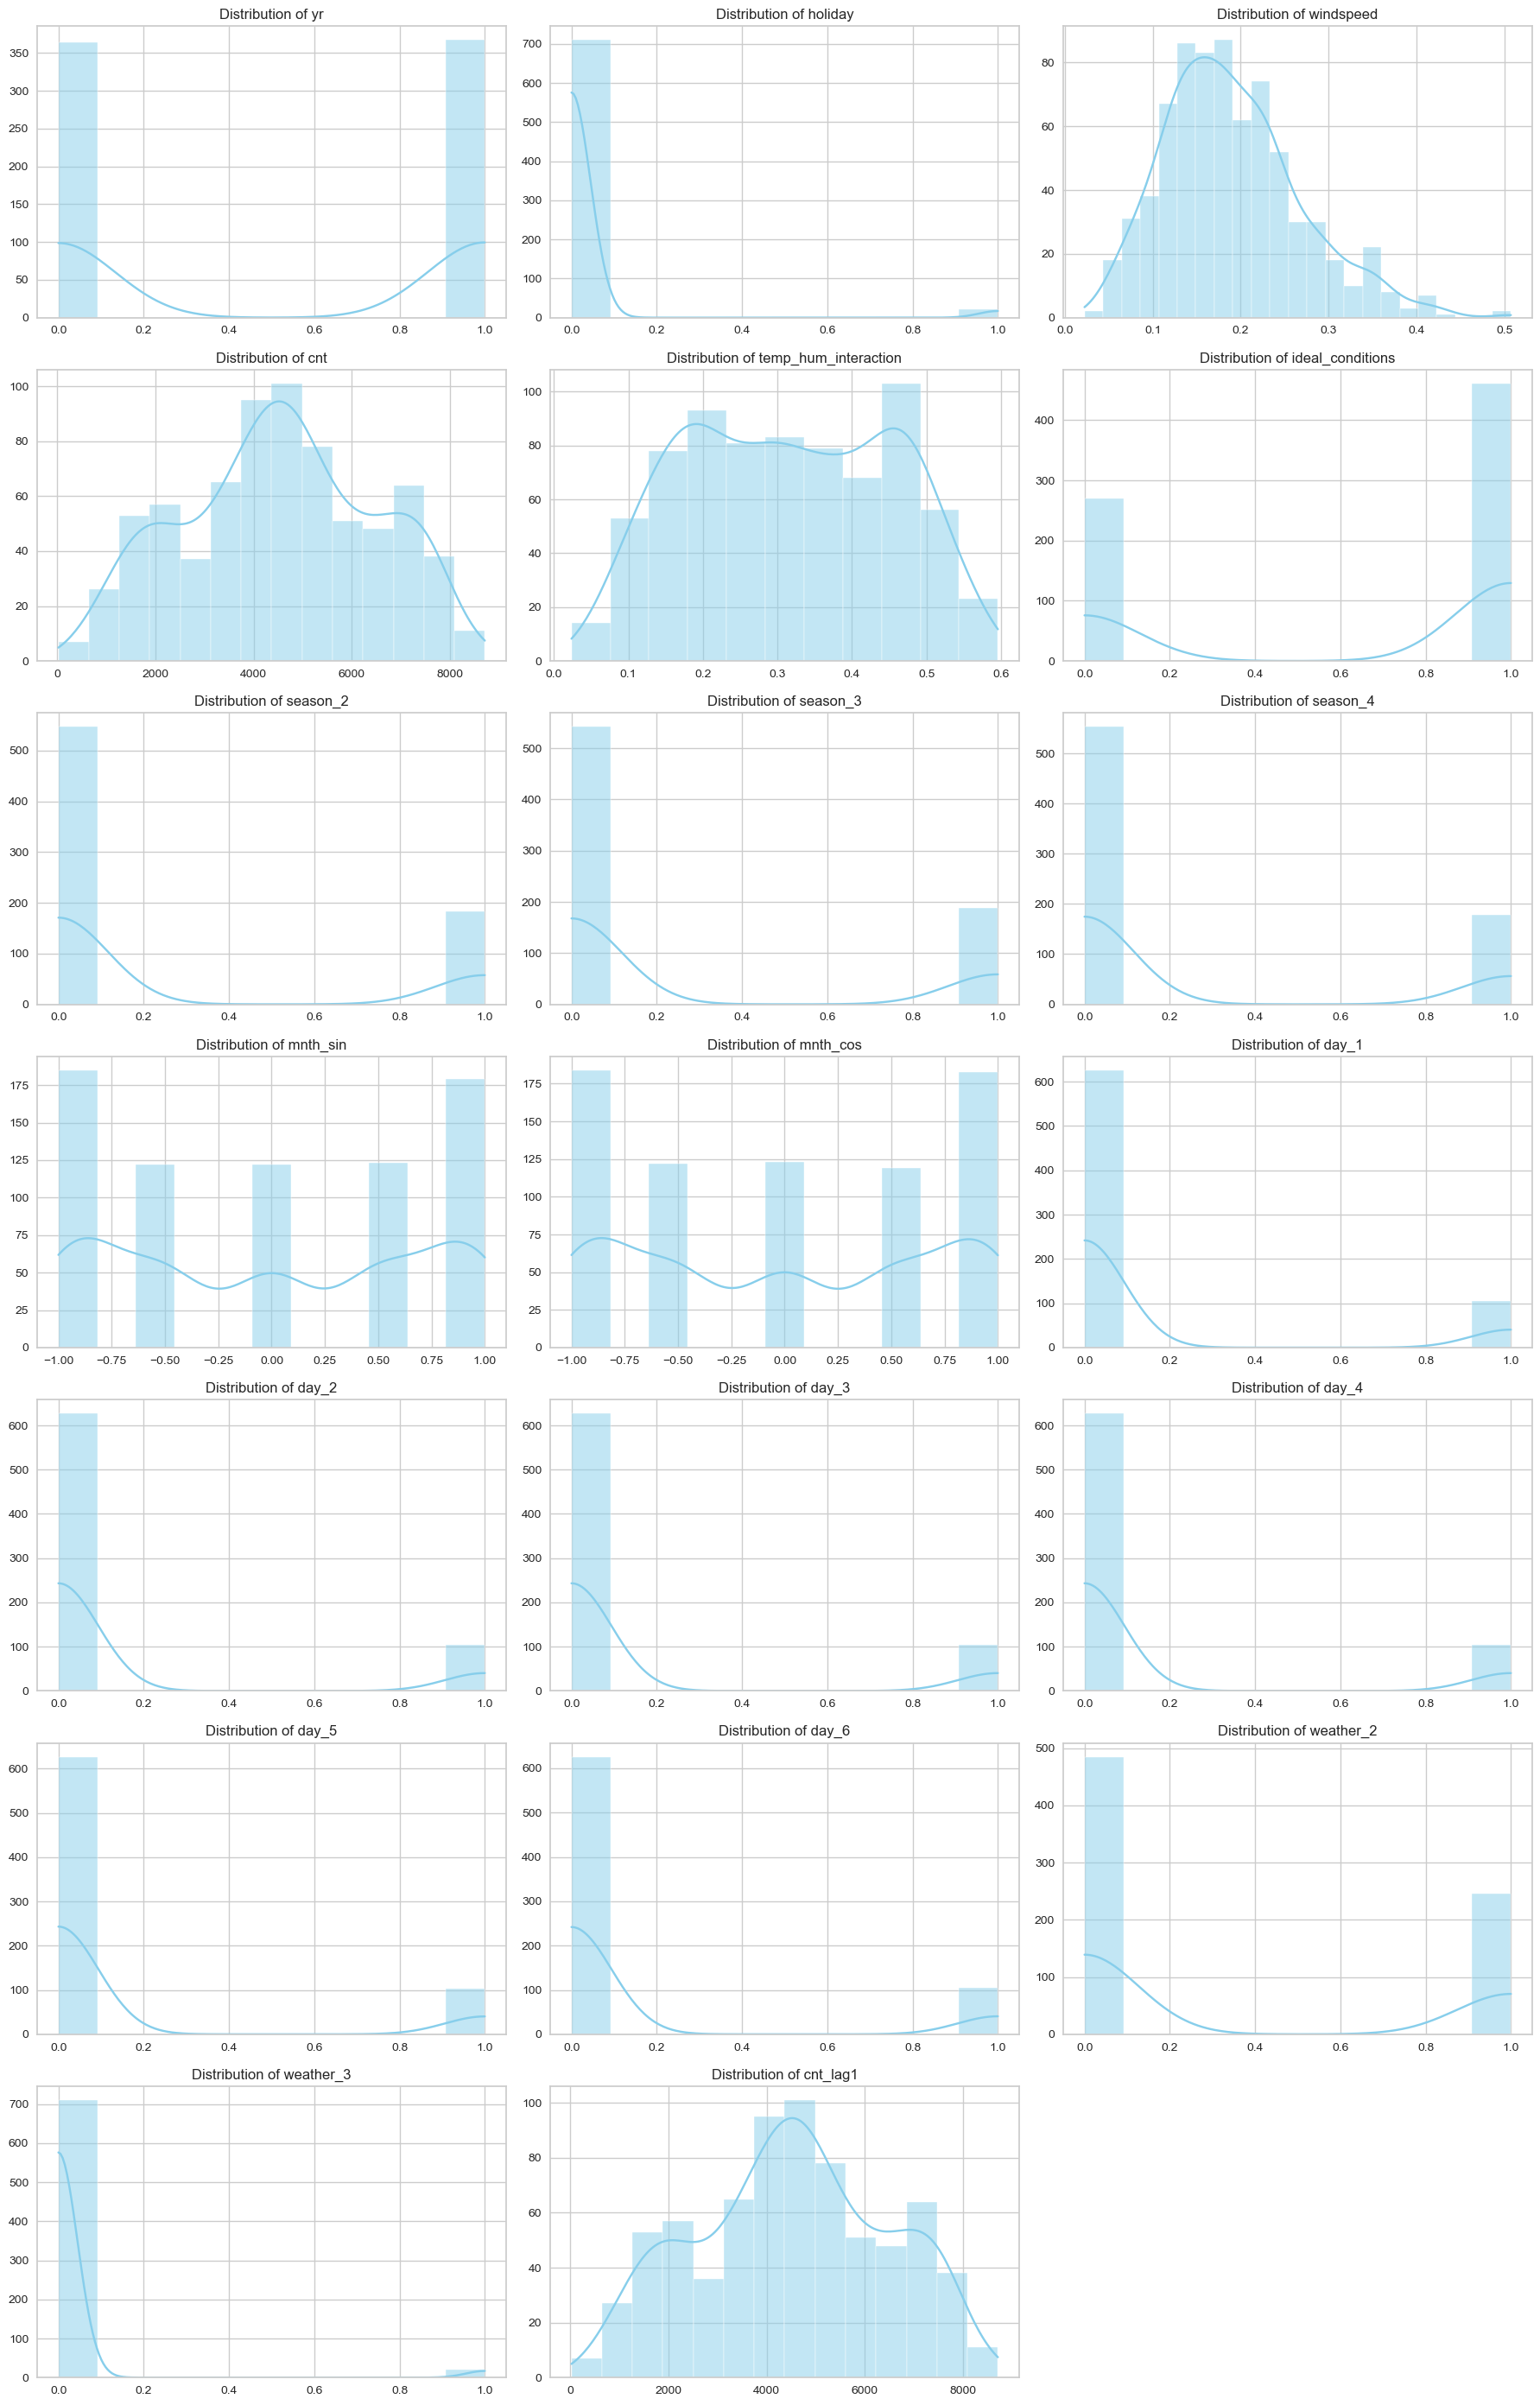

In [36]:
# Set the style
sns.set_style('whitegrid')

# Create a grid of plots
# We calculate the number of rows needed based on your column count
cols = ds.columns
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(ds[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Modeling

In [37]:
# target
X = ds
y = ds['cnt']                 

In [38]:
# Normalize training data
scaler = MinMaxScaler(feature_range=(0, 1))

# MinMax scaler returns an array, so the dataframe must be recreated
X_scaled = pd.DataFrame(scaler.fit_transform(X.values), columns=X.columns,index=X.index)

In [39]:
# Split the dataset intro train and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, train_size = 0.75, test_size = 0.25, random_state = 123)

In [40]:
# Remove the Target from the training
X_train = X_train.drop(columns=['cnt'])
X_test = X_test.drop(columns=['cnt'])

In [41]:
# Execute Randomized Search to hyper tune parameters
# This operation can take a long time to run (at least 5 minutes)
# For list of partameters check https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html
random_param = {'hidden_layer_sizes': [3,4,5,6,7,8],
          'activation': ['tanh', 'relu'],
          'solver':['lbfgs', 'adam'],
          'alpha':[0.0001, 0.002, 0.05],
          'batch_size':['auto'],
          'learning_rate':['constant'],
          'learning_rate_init':[0.001, 0.002],
          'max_iter':[100,300,500,700,900],
          'random_state':[123]}
reg = MLPRegressor()
rand = RandomizedSearchCV(reg, param_distributions=random_param, cv=5, n_iter = 20)
rand.fit(X_train.values, y_train)
print("Random search best parameters: {}".format(rand.best_params_))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF 

Random search best parameters: {'solver': 'lbfgs', 'random_state': 123, 'max_iter': 500, 'learning_rate_init': 0.001, 'learning_rate': 'constant', 'hidden_layer_sizes': 4, 'batch_size': 'auto', 'alpha': 0.05, 'activation': 'relu'}


In [42]:
# Create the model
estimator = MLPRegressor(**rand.best_params_)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF 

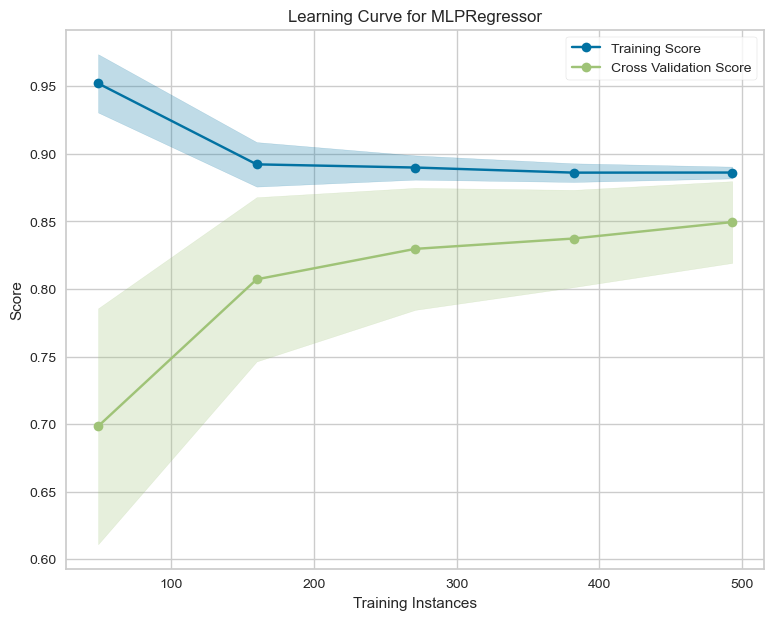

<Axes: title={'center': 'Learning Curve for MLPRegressor'}, xlabel='Training Instances', ylabel='Score'>

In [43]:
# Plot the learning curve
fig, ax = plt.subplots(figsize=(9, 7))
cv = 10
sizes = np.linspace(0.1, 1.0, 5)
visualizer = LearningCurve(estimator=estimator, cv=cv, scoring='r2', train_sizes=sizes, n_jobs=4, random_state=123, shuffle=False)
visualizer.fit(X_train.values, y_train)
visualizer.show(ax=ax)

In [44]:
# Create and train the model
estimator.fit(X_train.values, y_train)

MLPRegressor(alpha=0.05, hidden_layer_sizes=4, max_iter=500, random_state=123,
             solver='lbfgs')

#### Evaluation

In [45]:
# predict y for X_train and X_test
y_pred_train = estimator.predict(X_train.values) 
y_pred_test = estimator.predict(X_test.values) 

In [46]:
# Function to create dataframe with metrics
def performanceMetricsDF(metricsObj, yTrain, yPredTrain, yTest, yPredTest,set1='Train', set2='Test'):
  measures_list = ['MAE','RMSE', 'R^2','MAPE (%)','MAX Error']
  train_results = [metricsObj.mean_absolute_error(yTrain, yPredTrain),
                np.sqrt(metricsObj.mean_squared_error(yTrain, yPredTrain)),
                metricsObj.r2_score(yTrain, yPredTrain),
                metricsObj.mean_absolute_percentage_error(yTrain, yPredTrain),
                metricsObj.max_error(yTrain, yPredTrain)]
  test_results = [metricsObj.mean_absolute_error(yTest, yPredTest),
                np.sqrt(metricsObj.mean_squared_error(yTest, yPredTest)),
                metricsObj.r2_score(yTest, yPredTest),
                  metricsObj.mean_absolute_percentage_error(yTest, yPredTest),
                metricsObj.max_error(yTest, yPredTest)]
  resultsDF = pd.DataFrame({'Measure': measures_list, set1: train_results, set2:test_results})
  return(resultsDF)

In [47]:
# Show performance results
resultsDF = performanceMetricsDF(metrics, y_train, y_pred_train, y_test, y_pred_test)
resultsDF

,Measure,Train,Test
0,MAE,498.042098,471.057109
1,RMSE,664.699125,670.495790
2,R^2,0.884944,0.870245
3,MAPE (%),0.364766,0.134895
4,MAX Error,2877.499823,2805.617067


In [48]:
# Visualize predictions vs target values 
temp = y_test.to_frame()
temp['Prediction'] = y_pred_test
temp['Residual'] = y_test - temp.Prediction
temp

,cnt,Prediction,Residual
489,6296,6756.439875,-460.439875
422,4322,4642.903524,-320.903524
92,3249,3303.869446,-54.869446
301,627,1169.469264,-542.469264
178,4648,5211.647332,-563.647332
...,...,...,...
160,4586,4314.060494,271.939506
674,5107,4842.965922,264.034078
518,8120,7265.256150,854.743850
659,8090,7619.110619,470.889381


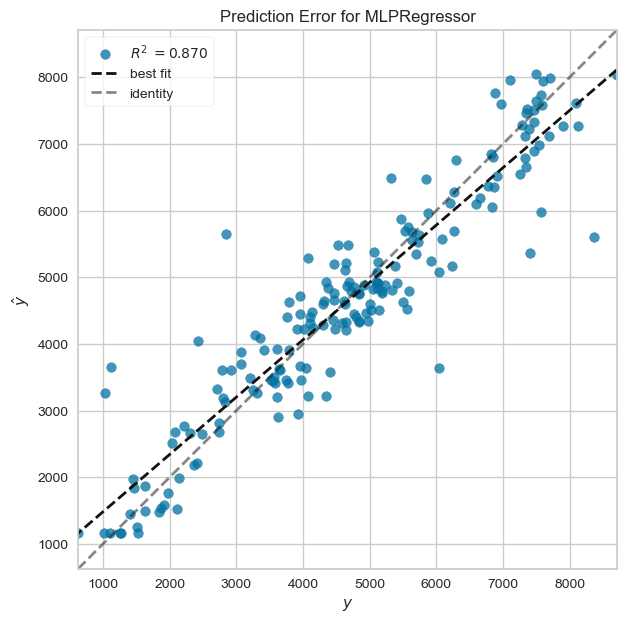

<Axes: title={'center': 'Prediction Error for MLPRegressor'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [49]:
# Visualize the prediction error
fig, ax = plt.subplots(figsize=(9, 7))
predError_vis = PredictionError(estimator)
predError_vis.fit(X_train.values, y_train)  # Fit the training data to the visualizer
predError_vis.score(X_test.values, y_test)  # Evaluate the model on the test data
predError_vis.show(ax=ax)

In [50]:
import pickle

# 1. Save the Best Model from your Randomized Search
with open("nn_model.pickle", "wb") as f:
    pickle.dump(rand.best_estimator_, f)

# 2. Save the Scaler you used on X
with open("scaler.pickle", "wb") as f:
    pickle.dump(scaler, f)

print("Deployment Pack Saved: Model and Scaler are ready.")

Deployment Pack Saved: Model and Scaler are ready.
